# 项目：可视化帕默群岛企鹅数据

## 分析目标

此数据分析报告的目的是对帕默群岛上企鹅样本的相关变量进行可视化，从而探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系。

## 简介

原始数据`Penguins.csv`包括334个收集自南极洲帕尔默群岛的3个岛屿上的企鹅样本，以及企鹅相关属性数据，包括种类名、所在岛、嘴峰长度、嘴峰深度、鳍长度、体重、性别。

`Penguins.csv`每列的含义如下：
- species：企鹅的种类
- island：企鹅所在岛
- culmen_length_mm：企鹅嘴峰的长度（单位为毫米）
- culmen_depth_mm：企鹅嘴峰的深度（单位为毫米）
- flipper_length_mm：企鹅鳍的长度（单位为毫米）
- body_mass_g：企鹅体重（单位为克）
- sex：企鹅性别

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
original_data = pd.read_csv('penguins.csv')
original_data.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [52]:
cleaned_data = original_data.copy()


# 数据清洗

## 数据整齐度

In [53]:
cleaned_data.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


整体上看，每个变量为一列 每个个体为一行，不存在结构性问题

## 数据干净度

In [54]:
#通过info()方法查看数据集的基本信息，包括数据类型、非空值数量等
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


从输出结果来看，`cleaned_data`数据共有344条观察值，`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`变量存在缺失值，将在后续进行评估和清理。

数据类型方面，我们已知`species`（企鹅种类）`sex`（企鹅性别）、`island`（企鹅所在岛）都是分类数据，因此可以把数据类型都转换为Category。

In [55]:
#将'species'、'island'和'sex'列的数据类型转换为类别型（category），以便在后续分析中更好地处理这些分类变量
cleaned_data['species'] = cleaned_data['species'].astype('category')
cleaned_data['island'] = cleaned_data['island'].astype('category')
cleaned_data['sex'] = cleaned_data['sex'].astype('category')

In [56]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.3 KB


## 处理缺失数据

从`info`方法的输出来看，在`cleaned_data`中，`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`、`sex`变量存在缺失值。

先提取出缺失这些变量的观察值进行查看。

In [57]:
cleaned_data.query('culmen_length_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [58]:
cleaned_data.query('culmen_depth_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [59]:
cleaned_data.query('flipper_length_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [60]:
cleaned_data.query('body_mass_g.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [61]:
cleaned_data.query('sex.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


以上，可以看到索引为3和339的观察值，除了种类和所属岛屿外所有变量都为空，无法为探索企鹅身体属性相关因素提供价值，因此可以把这两行直接删除。缺失性别变量的观察值具备其它数据，仍然可以为分析提供价值。由于Pandas以及Matplotlib、Seaborn会自动忽略缺失值，可以保留这些行。

In [62]:
cleaned_data.drop(3, inplace=True)
cleaned_data.drop(339, inplace=True)

## 处理重复数据

根据数据变量的含义以及内容来看，允许变量重复，我们不需要对此数据检查是否存在重复值。

## 处理不一致数据

不一致数据可能存在于所有分类变量中，我们要查看`species`,`sex`,`island`是否存在不同值实际指代同一目标的情况。

In [63]:
cleaned_data['species'].value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

In [64]:
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [65]:
cleaned_data['island'].value_counts()

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

可以看到sex里面有一个性别为.是错误数据

In [66]:
#将'sex'列中的点号替换为NaN
cleaned_data['sex'] = cleaned_data['sex'].replace(".", np.nan)


C:\Users\Edwin\AppData\Local\Temp\ipykernel_15864\2436931974.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cleaned_data['sex'] = cleaned_data['sex'].replace(".", np.nan)


In [70]:
# 再次查看'sex'列的值分布
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

异常数据已被剔除，sex不再存在不一致数据

## 处理无效或错误数据

通过DataFrame的`describe`方法，对数值统计信息进行快速了解。

In [71]:
cleaned_data.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


从以上统计信息来看，`cleaned_house_price`里不存在脱离现实意义的数值。

# 探索数据

将通过数据可视化，进行探索和分析，从图表中获得企鹅样本数据的相关洞察。

In [73]:
# 设置色盘颜色pastel
sns.set_palette('pastel')

In [74]:
cleaned_data


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


## 企鹅种类比例

In [76]:
species_counts = cleaned_data['species'].value_counts()

([<matplotlib.patches.Wedge at 0x1089a775310>,
 [Text(0.20095570279004357, 1.0814882364206093, 'Adelie'),
  Text(-0.7954730250570456, -0.7597517136582143, 'Gentoo'),
  Text(0.892288738448971, -0.6432890541872635, 'Chinstrap')],
 [Text(0.10961220152184194, 0.5899026744112414, '44%'),
  Text(-0.433894377303843, -0.41441002563175316, '36%'),
  Text(0.48670294824489324, -0.3508849386475982, '20%')])

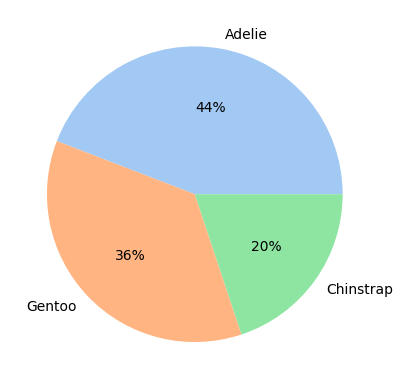

In [82]:
#绘制饼图
plt.pie(species_counts,autopct = "%.0f%%" ,labels = species_counts.index)

其中`adelie`最多，`gentoo`次之,`chinstrap`最少

## 企鹅所属岛屿所占比例

([<matplotlib.patches.Wedge at 0x1089a7c8cd0>,
 [Text(0.040408993903112124, 1.0992575281578645, 'Biscoe'),
  Text(-0.5324063168406664, -0.9625713032228604, 'Dream'),
  Text(0.9814795839173, -0.49668684938653646, 'Torgersen')],
 [Text(0.022041269401697518, 0.5995950153588351, '49%'),
  Text(-0.2904034455494544, -0.5250388926670148, '36%'),
  Text(0.5353525003185272, -0.2709200996653835, '15%')])

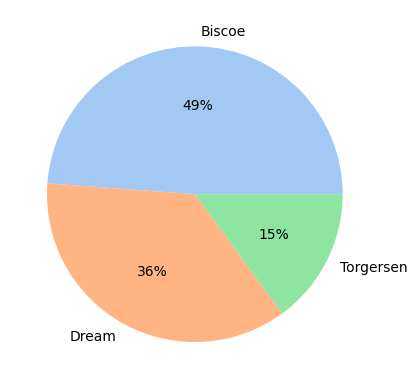

In [83]:
island_counts = cleaned_data['island'].value_counts()
plt.pie(island_counts,autopct = "%.0f%%" ,labels = island_counts.index)

有一半的企鹅都在`Biscoe`岛上

## 企鹅性别比例

([<matplotlib.patches.Wedge at 0x1089a7cbc50>,
 [Text(-0.01556599676421093, 1.0998898580061263, 'MALE'),
  Text(0.015565699568373776, -1.0998898622120976, 'FEMALE')],
 [Text(-0.008490543689569597, 0.5999399225487961, '50%'),
  Text(0.008490381582749331, -0.5999399248429623, '50%')])

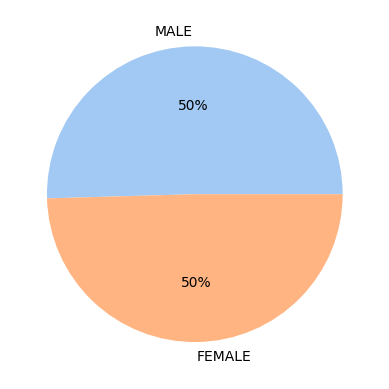

In [84]:
sex_counts = cleaned_data['sex'].value_counts()
plt.pie(sex_counts,autopct = "%.0f%%" ,labels = sex_counts.index)

性别比例1：1符合随机抽样

## 不同岛上的企鹅种类

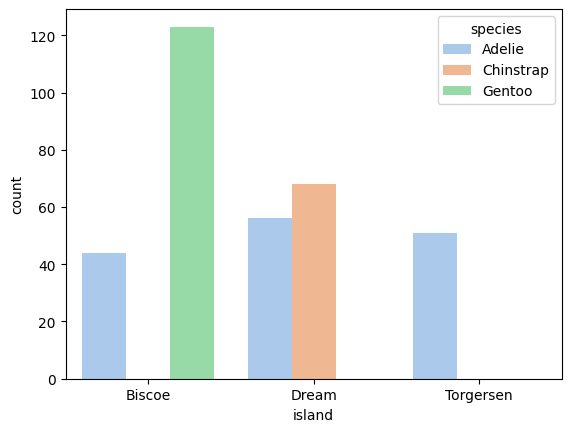

In [86]:
sns.countplot(cleaned_data, x = 'island', hue = 'species')
plt.show()

从以上可以看出，`Adelie`种类的企鹅样本在 Biscoe、Dream、Torgersen 这三个岛上都有，而`Chinstrap`种类只在 Dream 岛上才有，`Gentoo`只在 Biscoe 岛上才有。


## 不同岛屿的性别数量

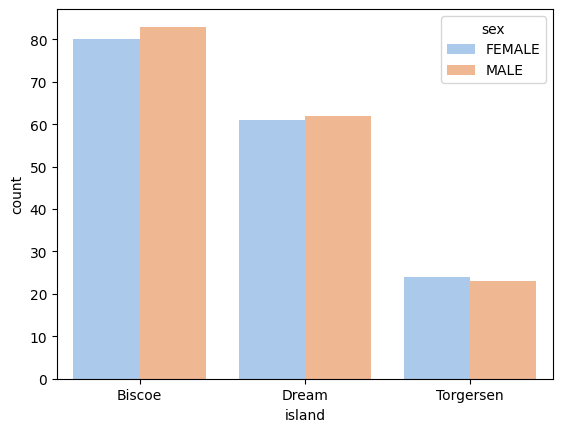

In [88]:
sns.countplot(cleaned_data, x='island',hue='sex')
plt.show()

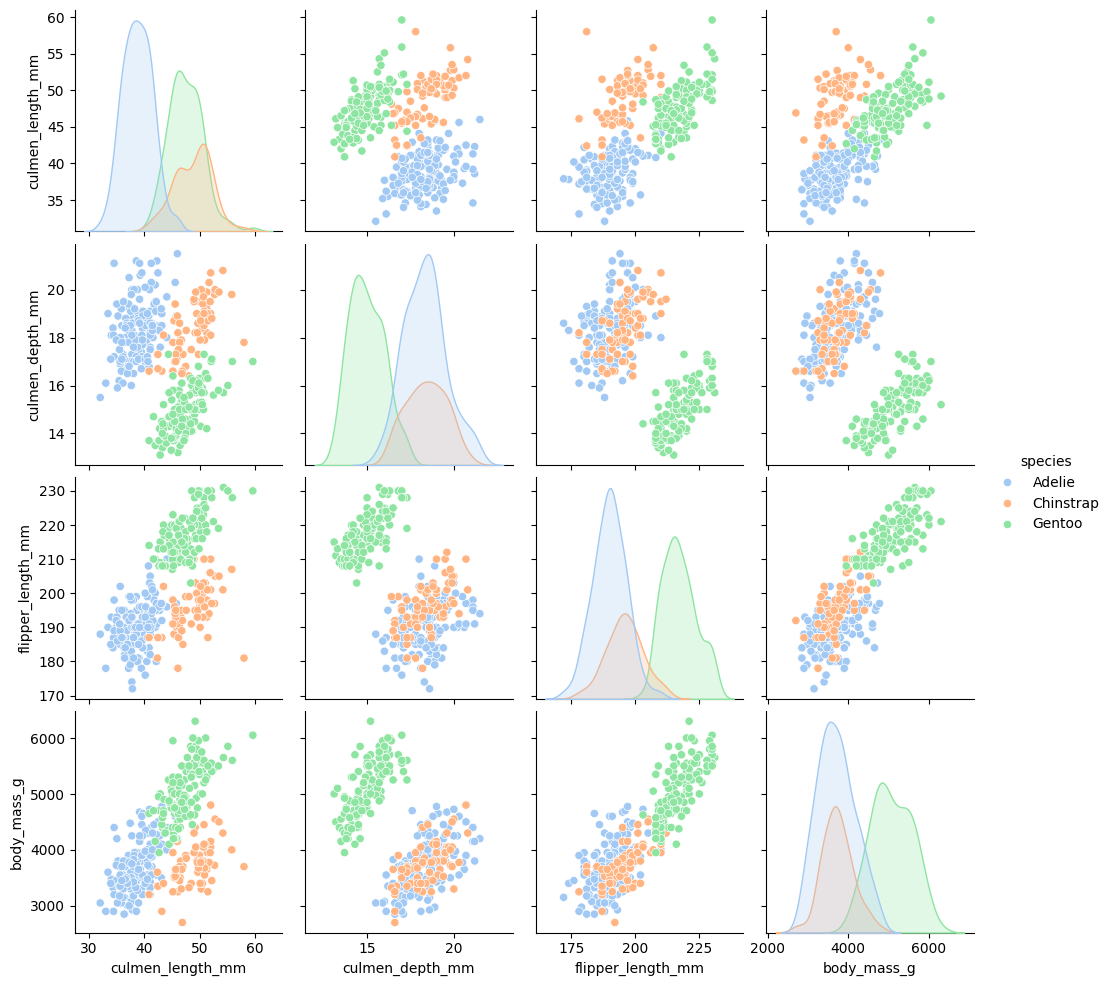

In [89]:
sns.pairplot(cleaned_data, hue='species' )
plt.show()


不同种类的企鹅样本数据，在散点图上基本都聚在一起，说明同一种类的企鹅在**嘴峰长度**、**嘴峰深度**、**鳍长度**、**体重**之间的关系上存在较强的区分性。这些观测结果表明可以根据体重、鳍长等数值推测企鹅种类，也可以根据企鹅种类推测体重、鳍长等数值。

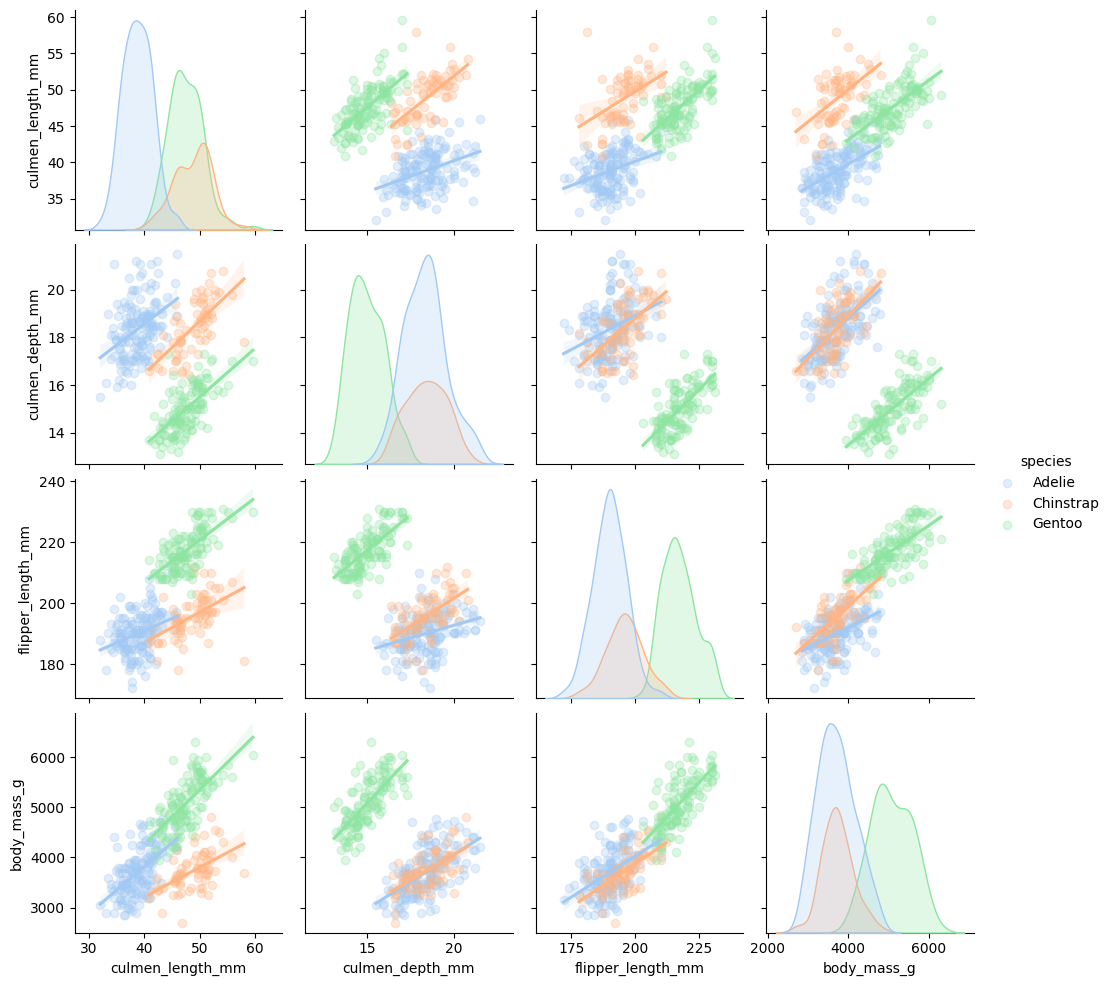

In [ ]:
#kind='reg'表示在散点图中添加回归线，plot_kws={'scatter_kws':{'alpha':0.3}}表示设置散点图的透明度为0.3，以便更好地观察数据点的分布情况
sns.pairplot(cleaned_data, hue='species',kind='reg',plot_kws={'scatter_kws':{'alpha':0.3}} )
plt.show()


<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

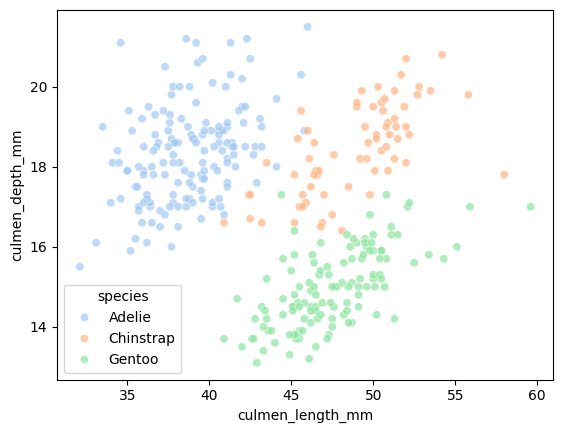

In [96]:
sns.scatterplot(cleaned_data, x='culmen_length_mm', y='culmen_depth_mm', hue='species', alpha=0.7)

整体散点图相关性回归结果，同种类企鹅的属性数据之间均呈现线性正比，即**嘴峰长度**、**嘴峰深度**、**鳍肢长度**、**体重**，随着其中一项数值增大，其余几项也随之增大。

散点图结合线性回归线来看，同类企鹅的属性数据之间均呈线性正比，即嘴峰越长，嘴峰越深，鳍越长，体重越重，嘴峰越短，嘴峰越浅，鳍越短，体重越轻。

从密度图的分布来看，可以得到以下关于样本的发现：

- `Chinstrap`和`Gentoo`的嘴峰长度范围较为接近，而`Adelie`的嘴峰长度更短。
- `Adelie`和`Chinstrap`的嘴峰深度范围较为接近，而`Gentoo`的嘴峰深度更短。
- `Adelie`的鳍长度最短，`Chinstrap`中等，而`Gentoo`的鳍长度最长。
- `Adelie`和`Chinstrap`的体重范围较为接近，而`Gentoo`的体重更大。

但不同种类的属性数值否存在统计显著性差异，仍然需要进行假设检验后才能得到结论。

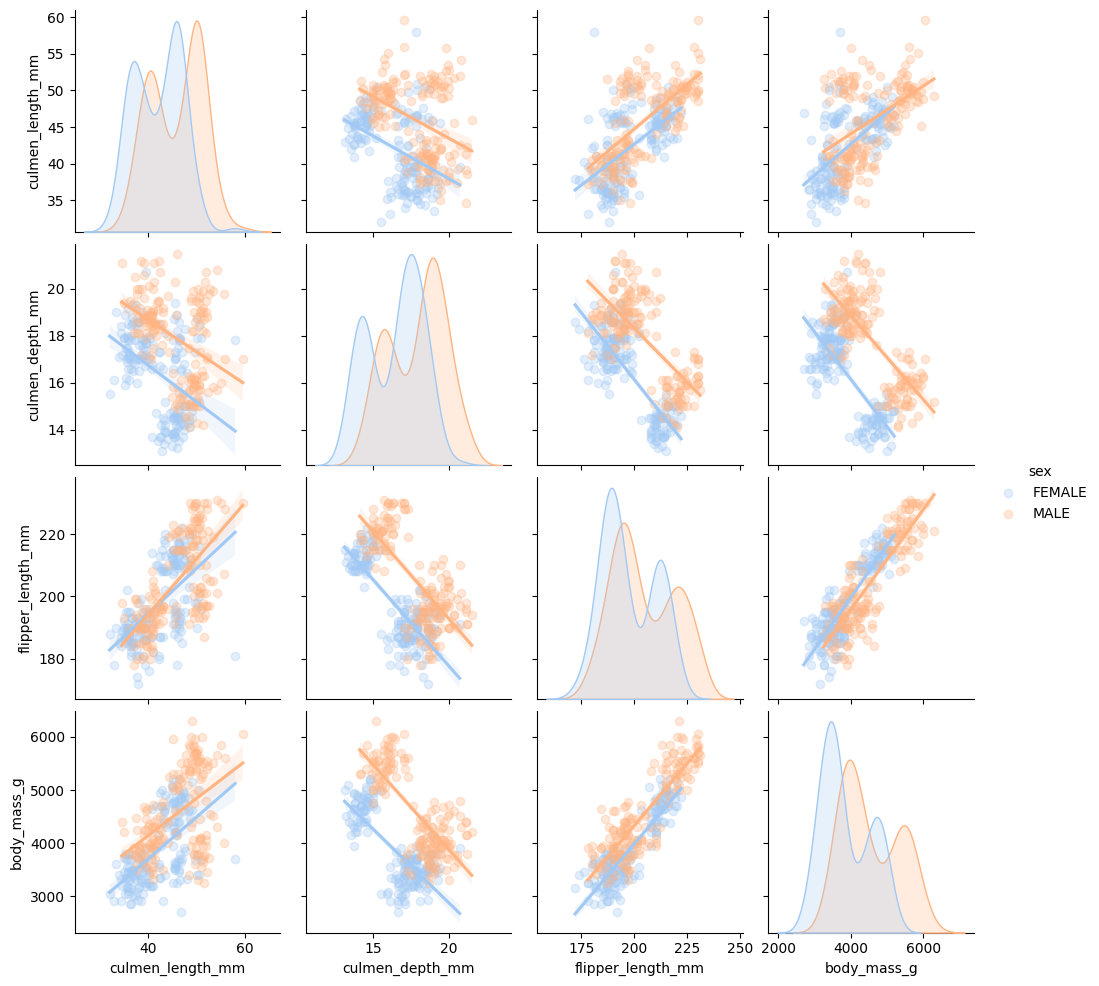

In [97]:

sns.pairplot(cleaned_data, hue='sex',kind='reg',plot_kws={'scatter_kws':{'alpha':0.3}} )
plt.show()

根据性别划分后可以看出，样本中雄性企鹅在各项属性数值方面大于雌性企鹅。